# **CONVOLUTIONAL NEURAL NETWORK**

- ## Modules

In [126]:
import os
import random
import pathlib
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [96]:
# Checking wheather the gpu is available or not as well as the version of tensorflow(tf)
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            print("GPU available:", gpus)
    except RuntimeError as e:
        print(e)
else:
    print("GPU not available")

TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [97]:
# Taking direct url from kaggle for the brain tumour dataset
ds_path = kagglehub.dataset_download("ramanarasimhakanduri/brain-tumour-dataset")
data_path = os.path.join(ds_path, "final_dataset_clean")

In [98]:
# Exploring classes 
class_names = sorted(os.listdir(data_path))
print("Classes:", class_names)
print("Total number of classes:", len(class_names))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Total number of classes: 4


In [99]:
# Image counting in all classes
image_count = {}
for class_name in class_names:
    class_path = os.path.join(data_path, class_name)
    total_images = len(os.listdir(class_path))
    image_count[class_name] = total_images
    print(f"{class_name}: {total_images}")

glioma: 1734
meningioma: 1625
notumor: 1870
pituitary: 1663


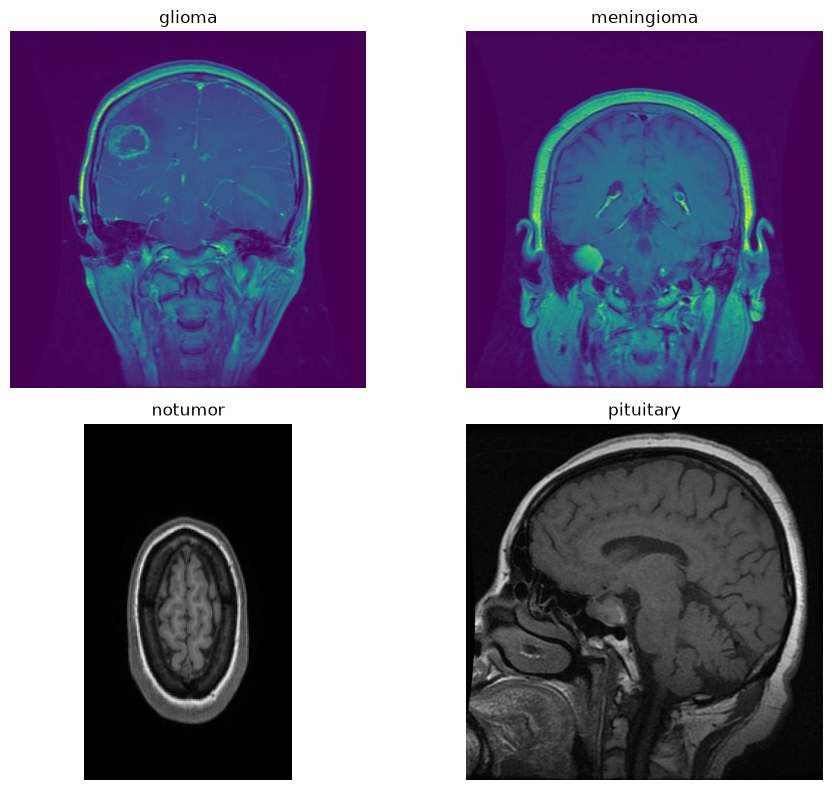

In [100]:
# Seeing the image visually
plt.figure(figsize=(10, 8))
for index, class_name in enumerate(class_names):
    class_path = os.path.join(data_path, class_name)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)
    image = plt.imread(image_path)
    plt.subplot(2, 2, index + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")
plt.tight_layout()

Class: notumor
Image name: brisc2025_train_03272_no_sa_t1.jpg
Image shape: (369, 369, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 247


(np.float64(-0.5), np.float64(368.5), np.float64(368.5), np.float64(-0.5))

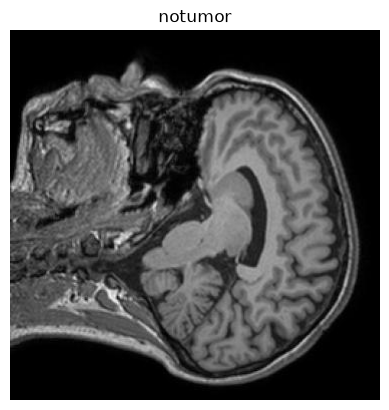

In [101]:
# Image Properties
sample_class = random.choice(class_names)
class_path = os.path.join(data_path, sample_class)
image_name = random.choice(os.listdir(class_path))
image_path = os.path.join(class_path, image_name)
image = plt.imread(image_path)
print("Class:", sample_class)
print("Image name:", image_name)
print("Image shape:", image.shape)
print("Data type:", image.dtype)
print("Minimum pixel value:", image.min())
print("Maximum pixel value:", image.max())
plt.imshow(image)
plt.title(sample_class)
plt.axis("off")

In [102]:
# Creating a list of all images
image_paths = []
image_labels = []
for class_index, class_name in enumerate(class_names):
    class_path = os.path.join(data_path, class_name)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        image_paths.append(image_path)
        image_labels.append(class_index)
print("Total images:", len(image_paths))
print("Total labels:", len(image_labels))

Total images: 6892
Total labels: 6892


In [103]:
# 80% Training, 20% Temporary
x_train, x_temp, y_train, y_temp = train_test_split(
    image_paths,
    image_labels,
    test_size=0.20,
    random_state=42,
    stratify=image_labels
)

# Dividing the temporary 20% equally into Validation and Testing 
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training images:", len(x_train))
print("Validation images:", len(x_val))
print("Testing images:", len(x_test))

Training images: 5513
Validation images: 689
Testing images: 690


In [104]:
# Resizing the image and giving the batch size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [105]:
# Image loading function
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

In [107]:
# Creating Tensorflow dataset
train_dataset = tf.data.Dataset.from_tensor_slices(
    (x_train, y_train)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (x_val, y_val)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (x_test, y_test)
)

train_dataset = train_dataset.map(load_image)
val_dataset = val_dataset.map(load_image)
test_dataset = test_dataset.map(load_image)

In [108]:
# Shuffling the classes to make the training more faster
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [110]:
# Checking the dataset shape
for images, labels in train_dataset.take(1):
    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)
    print("First 5 Labels :", labels[:5].numpy())

Image Batch Shape : (32, 128, 128, 3)
Label Batch Shape : (32,)
First 5 Labels : [1 2 0 1 3]


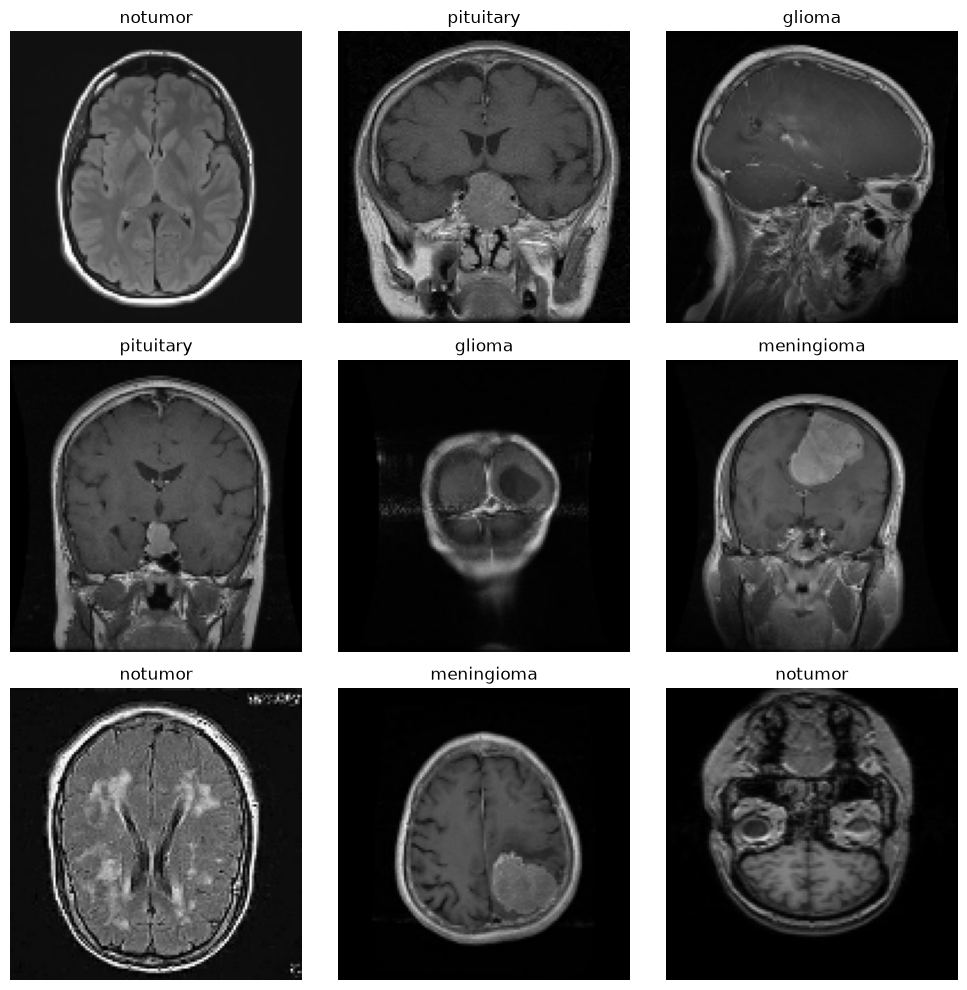

In [111]:
plt.figure(figsize=(10,10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()

In [112]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [114]:
# CNN Architecture
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    data_augmentation,
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),
    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),
    tf.keras.layers.Dense(
        len(class_names),
        activation="softmax"
    )
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,296,196 (16.39 MB)

 Trainable params: 4,296,196 (16.39 MB)

 Non-trainable params: 0 (0.00 B)

In [116]:
# Compiling
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [117]:
# Training
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20


/home/dhruv/venvs/tf-gpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788709515.487158   50379 cuda_dnn.cc:461] Loaded cuDNN version 92501


173/173 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.6127 - loss: 0.9290 - val_accuracy: 0.6459 - val_loss: 0.9331
Epoch 2/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.7606 - loss: 0.6289 - val_accuracy: 0.7750 - val_loss: 0.6039
Epoch 3/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.8066 - loss: 0.5098 - val_accuracy: 0.7983 - val_loss: 0.5455
Epoch 4/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.8413 - loss: 0.4302 - val_accuracy: 0.8200 - val_loss: 0.5019
Epoch 5/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.8562 - loss: 0.3797 - val_accuracy: 0.8447 - val_loss: 0.4028
Epoch 6/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.8756 - loss: 0.3322 - val_accuracy: 0.8781 - val_loss: 0.3751
Epoch 7/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.8817 - loss: 0.3176 - val_accuracy: 0.8229 - val_loss: 0.5096
Epoch 8/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.9010 - loss: 0.2741 - val_accuracy: 0.87

### Training Results

The CNN model was trained for 20 epochs.

- Training accuracy increased from **61.27%** in Epoch 1 to **95.79%** in Epoch 20.
- Validation accuracy increased from **64.59%** in Epoch 1 to **94.05%** in Epoch 20.
- Training loss decreased from **0.9290** to **0.1141**.
- Validation loss decreased from **0.9331** to **0.2231**.
- The model achieved its best validation accuracy of approximately **94.05%** by the end of training.

Overall, the model learned well, with both training and validation accuracy improving significantly during training.

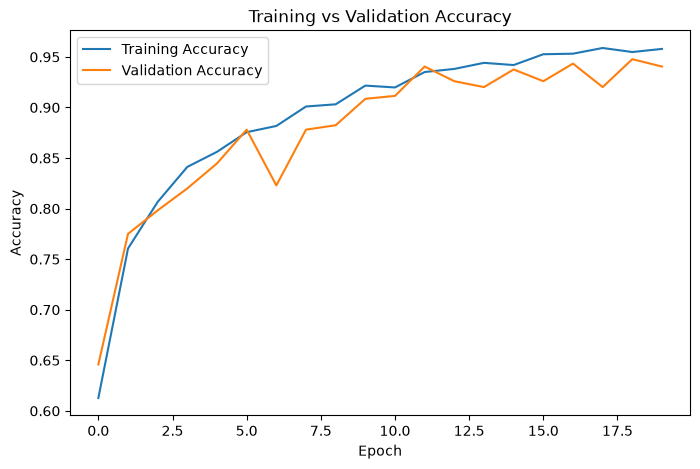

In [118]:
# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

### Training vs Validation Accuracy

- The graph shows that both training and validation accuracy increase with each epoch. 
- The model achieves approximately **96% training accuracy** and **94% validation accuracy**.
- The small gap between them indicates that the model is learning well without significant overfitting.

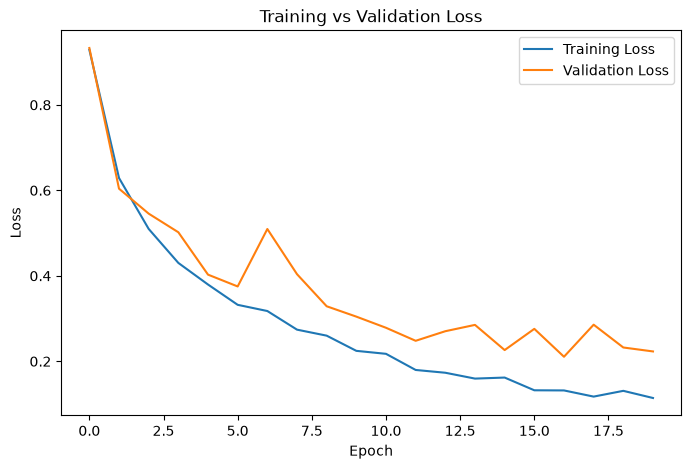

In [119]:
# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

### Training vs Validation Loss

- The graph shows that both training and validation loss generally decrease as the number of epochs increases.
- The model achieves approximately **0.11 training loss** and **0.22 validation loss** by the end of training.
- Overall, the decreasing loss indicates that the model is learning effectively.

In [120]:
# Evaluation
test_loss, test_accuracy = model.evaluate(test_dataset)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9377 - loss: 0.2461
Test Loss: 0.24610069394111633
Test Accuracy: 0.9376811385154724


### Test Evaluation

- The model achieved a **Test Accuracy of 93.77%** with a **Test Loss of 0.2461**. This shows that the trained CNN performs well on the unseen test dataset.

In [123]:
# Predictions
y_true = []
y_pred = []
for images, labels in test_dataset:
    predictions = model.predict(
        images,
        verbose=0
    )
    predicted_labels = np.argmax(
        predictions,
        axis=1
    )
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)
y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [125]:
# Classification report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.92      0.91      0.92       174
  meningioma       0.91      0.86      0.88       162
     notumor       0.93      0.98      0.96       187
   pituitary       0.98      0.99      0.99       167

    accuracy                           0.94       690
   macro avg       0.94      0.94      0.94       690
weighted avg       0.94      0.94      0.94       690



Text(0.5, 1.0, 'Confusion Matrix')

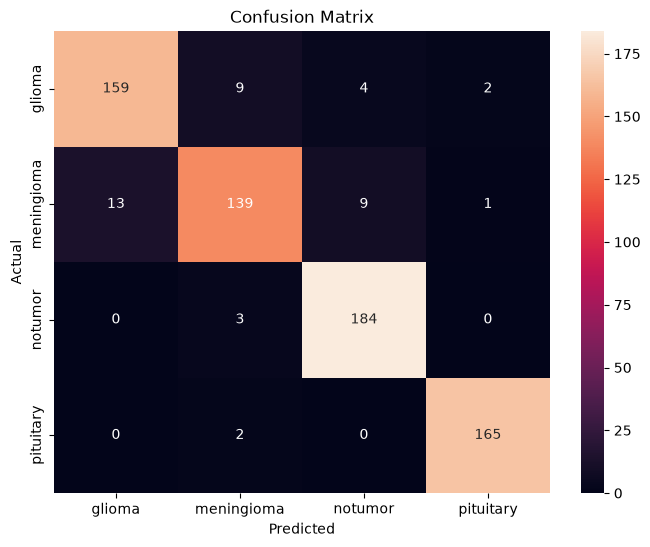

In [127]:
# Confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

In [130]:
# Test Image Pridiction
image_path = x_test[0]
image = tf.keras.utils.load_img(
    image_path,
    target_size=(128, 128)
)
image_array = tf.keras.utils.img_to_array(image)
image_array = image_array / 255.0
image_array = np.expand_dims(
    image_array,
    axis=0
)
prediction = model.predict(
    image_array,
    verbose=0
)
predicted_index = np.argmax(
    prediction[0]
)
print(
    "Predicted class:",
    class_names[predicted_index]
)
print(
    "Actual class:",
    class_names[y_test[0]]
)
print(
    "Confidence:",
    f"{prediction[0][predicted_index] * 100:.2f}%"
)

Predicted class: glioma
Actual class: glioma
Confidence: 97.87%


In [131]:
# Probability of each class
for index, probability in enumerate(prediction[0]):
    print(
        f"{class_names[index]}: "
        f"{probability * 100:.2f}%"
    )

glioma: 97.87%
meningioma: 2.13%
notumor: 0.00%
pituitary: 0.00%


In [132]:
# Model Save
model.save("brain_tumour_classifier.keras")